In [2]:
"""Check the output of the UQ"""
import xarray as xr
from utils.paths import *
from utils.analysis import *
import os
import itertools as it
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from matplotlib import rcParams
from glob import glob
from tqdm import tqdm
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, train_test_split, StratifiedKFold
from sklearn.utils import resample
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import LinearSVC, NuSVC, SVC


rcParams['font.size'] = 10
rcParams['axes.titlesize'] = 10
rcParams['figure.facecolor'] = 'w'
rcParams['axes.facecolor'] = 'w'

casename = 'UQ_default_US-SPR_ICB20TRCNPRDCTCBC'
casename_rerun = casename # casename.replace('UQ_default', 'UQ_default_optimized')
n_rerun = 4000
pft_list = [2, 3, 11, 12]
hol_add = 17
chamber_list = ['T0.00', 'T0.00CO2', 'T2.25', 'T2.25CO2', 'T4.50', 'T4.50CO2', 'T6.75', 'T6.75CO2', 'T9.00', 'T9.00CO2', 'TAMB']

<ipython-input-5-4d9c008356c5>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  index['year'] = [f'{i}-{j}' for i, j in zip(index['year_start'], index['year_end'])]
<ipython-input-5-4d9c008356c5>:30: PerformanceWarning: indexing past lexsort depth may impact performance.
  temp = allstats.loc[(var, pft), 'R2']


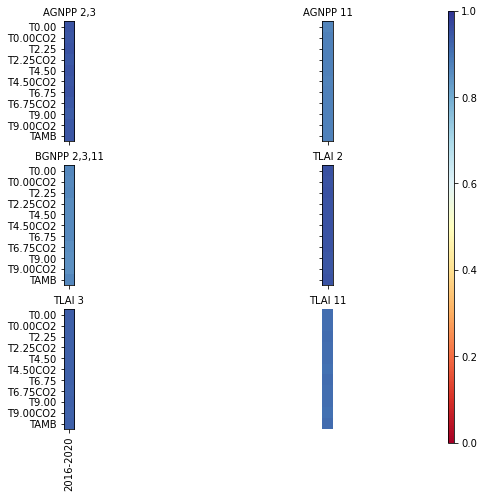

In [5]:
""" MCMC fitstats """

# Read the stats
filename = os.path.join(os.environ['HOME'], 'models', 'OLMT', 'UQ_output', casename, 'NN_surrogate', 'fitstats.txt')
f = open(filename, 'r')
allstats = [re.split(r'\s+', line.split(': ')[1]) for line in f.read().split('\n') if line[:3] == 'QOI']
allstats = pd.DataFrame([[float(line[0]), float(line[1])] for line in allstats], index = range(len(allstats)), columns = ['R2', 'RMSE'])
f.close()

# Read the column names
postproc_vars = pd.read_csv('./temp/postproc_vars_SPRUCE', sep = r'\s+')
index = postproc_vars.iloc[:, [0, 1, 2, 8, 11]]
index.columns = ['variable', 'year_start', 'year_end', 'pfts', 'chamber']
index['year'] = [f'{i}-{j}' for i, j in zip(index['year_start'], index['year_end'])]
index = index.drop(['year_start', 'year_end'], axis = 1)
allstats.index = pd.MultiIndex.from_frame(index)

# Make the plot
var_and_pft = index[['variable', 'pfts']].drop_duplicates()
fig, axes = plt.subplots(3, 2, figsize = (8.5, 7.5), sharex = True, sharey = True)
count = 0
for _, row in var_and_pft.iterrows():
    ax = axes.flat[count]

    var = row['variable']
    pft = row['pfts']
    ax.set_title(f'{var} {pft}')

    try:
        temp = allstats.loc[(var, pft), 'R2']
    except:
        ax.axis('off') # combination doesn't exist
        continue

    temp = temp.unstack()

    cf = ax.imshow(temp, vmin = 0, vmax = 1., cmap = 'RdYlBu')
    ax.set_xticks(range(temp.shape[1]))
    ax.set_xticklabels(temp.columns)
    plt.setp(ax.get_xticklabels(), rotation = 90)
    ax.set_yticks(range(temp.shape[0]))
    ax.set_yticklabels(temp.index)

    count += 1
axes.flat[-1].axis('off')
cax = fig.add_axes([0.92, 0.1, 0.01, 0.8])
plt.colorbar(cf, cax = cax, orientation = 'vertical')

In [4]:
""" Performance of the 1000 ELM runs sampled from the posterior parameter distributions """
###########################################################################################
# 1. Down-select to where all 4 PFTs grew
###########################################################################################
folders = [f'g{i:05g}' for i in range(1, n_rerun+1)]
# grew = np.full((n_rerun, len(pft_list)), True)
grew = np.full(n_rerun, True)
for i in tqdm(range(n_rerun)):
    pft_grew = True
    for chamber in chamber_list:
        flist = sorted(glob(os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', 'UQ', casename_rerun, folders[i], chamber, '*.h1.*.nc')))
        hr = xr.open_dataset(flist[0])
        gpp = hr['TLAI'].load() # * 86400 # s-1 to day-1
        for j, pft in enumerate(pft_list):
            if gpp[:, pft].max(axis = 0) < 1e-10:
                pft_grew = False
                break
                # grew[i, j] = False
            if gpp[:, pft + hol_add].max(axis = 0) < 1e-10:
                pft_grew = False
                break
                # grew[i, j] = False
        if pft_grew == False:
            hr.close()
            break
        hr.close()
    grew[i] = pft_grew
folders_grew = [f for i, f in enumerate(folders) if grew[i]]
folders_grew

with open('./temp/folders_grew.pkl', 'wb') as f:
    pickle.dump(folders_grew, f)

100%|██████████| 4000/4000 [42:09<00:00,  1.58it/s]  


TypeError: write() argument must be str, not bytes

In [7]:
folders_grew, len(folders_grew)

(['g00003',
  'g00005',
  'g00007',
  'g00028',
  'g00032',
  'g00038',
  'g00039',
  'g00052',
  'g00057',
  'g00066',
  'g00067',
  'g00068',
  'g00081',
  'g00082',
  'g00083',
  'g00085',
  'g00101',
  'g00107',
  'g00111',
  'g00118',
  'g00119',
  'g00122',
  'g00123',
  'g00128',
  'g00129',
  'g00140',
  'g00145',
  'g00147',
  'g00153',
  'g00157',
  'g00168',
  'g00169',
  'g00173',
  'g00176',
  'g00192',
  'g00203',
  'g00205',
  'g00206',
  'g00208',
  'g00210',
  'g00211',
  'g00235',
  'g00245',
  'g00251',
  'g00252',
  'g00263',
  'g00266',
  'g00267',
  'g00270',
  'g00271',
  'g00272',
  'g00277',
  'g00280',
  'g00292',
  'g00298',
  'g00299',
  'g00302',
  'g00316',
  'g00323',
  'g00326',
  'g00327',
  'g00335',
  'g00339',
  'g00345',
  'g00350',
  'g00355',
  'g00356',
  'g00361',
  'g00367',
  'g00376',
  'g00377',
  'g00381',
  'g00384',
  'g00387',
  'g00392',
  'g00394',
  'g00403',
  'g00417',
  'g00434',
  'g00436',
  'g00437',
  'g00445',
  'g00447',
  'g

In [66]:
# in the optimized parameters, PFT3 and 11 never grew
# In [27]: grew.sum(axis = 0)
# Out[27]: array([3663,  183,    0, 4000])
grew.sum(axis = 0)

array([ 203,  999,    0, 1000])

In [3]:
###########################################################################################
# 2. Extract the variables and compare to the postproc file
#    All variables will take > 6 hours, check TLAI of ambient, lala
###########################################################################################
observation = pd.read_csv(os.path.join(os.environ['HOME'], 'Git', 'phenology_elm', 'temp', 'postproc_vars_SPRUCE'), sep = r'\s+', header = None, skiprows = 1)
observation.columns = ['Variable','Startyear','Endyear','Startday','Endday','AveragingPeriod','Factor','AddOffset','PFT','Obs','Obs_err','Treatment']

observation = observation.loc[(observation['Variable'] == 'TLAI') & (observation['Treatment'] == 'T0.00'), :].reset_index(drop = True)
print(observation)

with open('./temp/folders_grew.pkl', 'rb') as f:
    folders_grew = pickle.load(f)

simulation = pd.DataFrame(np.nan, index = range(observation.shape[0]), columns = folders_grew)
for i in tqdm(range(len(folders_grew))):
    for j, row in observation.iterrows():
        filename = sorted(glob(os.path.join(os.environ['PROJDIR'], 'E3SM', 'output', 'UQ', casename_rerun, folders_grew[i], row.loc['Treatment'], 
                                            f'{casename_rerun}.clm2.h1.*-01-01-00000.nc')))[:-1]
        tvec = pd.date_range('2015-01-01', '2021-12-31', freq = '1D')
        tvec = tvec[~((tvec.month == 2) & (tvec.day == 29))]
        hr = xr.open_mfdataset(filename)
        val = hr[row.loc['Variable']][(tvec.dayofyear >= row.loc['Startday']) & (tvec.dayofyear <= row.loc['Endday']), :].load().mean(axis = 0)
        val_sum = row.loc['AddOffset']
        for pft, factor in zip(row['PFT'].split(','), row['Factor'].split(',')):
            pft = int(pft)
            val_sum = val_sum + (val[pft] * float(factor) * 0.64 + val[pft + hol_add] * float(factor) * 0.36)
        simulation.loc[j, folders_grew[i]] = val_sum
        hr.close()

  Variable  Startyear  Endyear  Startday  Endday  AveragingPeriod  \
0     TLAI       2016     2020       274     304              155   
1     TLAI       2016     2020       274     304              155   
2     TLAI       2016     2020       213     243              155   

                Factor  AddOffset PFT       Obs   Obs_err Treatment  
0  0.20822299651567944          0   2  0.600492  0.150123     T0.00  
1  0.08097560975609758          0   3  0.450308  0.045031     T0.00  
2   0.1445993031358885          0  11  0.184165  0.046041     T0.00  


100%|██████████| 625/625 [38:40<00:00,  3.71s/it]


In [4]:
###########################################################################################
# 3. Check what parameter combinations increase the TLAI of PFT 3
###########################################################################################
def param_list(filename):
    params = []
    f = open(os.path.join('./temp', filename))
    while True:
        line = f.readline()
        if not line:
            break
        if line == '\n':
            continue
        if line[0] == '#':
            continue
        params.append((line.split(' ')[0], line.split(' ')[1]))
    f.close()
    params = pd.MultiIndex.from_tuples(params, names = ['Parameter', 'PFT'])
    params = params.reorder_levels([1, 0])
    return params

mcsamples = pd.read_csv(os.path.join(os.environ['HOME'], 'models', 'OLMT', 'mcsamples_UQ_default_4000.txt'), sep = r'\s+', header = 0)
mcsamples.columns = param_list('parm_list_SPRUCE_default_no_sphagnum_second_trial')
mcsamples_min = mcsamples.min(axis = 0)
mcsamples_max = mcsamples.max(axis = 0)

top20 = simulation.loc[1, :].sort_values()[::-1].index[:20]
top20_vals = simulation.loc[1, :].sort_values()[::-1].values[:20]
mcsamples = mcsamples.loc[[int(g[1:]) for g in top20], :]

# Test individual parameter values
fig, axes = plt.subplots(nrows=6, ncols=5, figsize=(20, 20))
fig.subplots_adjust(hspace=0.3, wspace=0.1)

# Iterate over the axes and columns, creating histograms and median annotations
for ax, column in zip(axes.flatten(), mcsamples.columns):
    # Plot the histogram for the current column
    ax.hist(mcsamples[column], bins=5, alpha=0.75, color='steelblue', edgecolor='black')

    # Calculate the median and add a vertical line
    median = mcsamples[column].median()
    ax.axvline(median, color='red', linestyle='dashed', linewidth=2)

    # Annotate the median value
    ax.text(0.65, 0.85, f'Median: {median:.2f}', transform=ax.transAxes, fontsize=10, color='red')

    # Set the title and labels for the current subplot
    ax.set_title(f'Histogram of Column {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frequency')

    ax.set_xlim([mcsamples_min.loc[column], mcsamples_max.loc[column]])

# Remove any remaining empty subplots
for i in range(len(mcsamples.columns), 30):
    fig.delaxes(axes.flatten()[i])

# Test ratios between parameters
fig, axes = plt.subplots(3, 3, figsize = (12, 12))
for ax, col in zip(axes.flatten(), ['br_mr', 'flnr', 'froot_leaf', 'grperc', 'mbbopt', 'q10_mr', 'slatop']):
    temp = mcsamples.loc[:, [('2', col), ('3', col), ('11', col)]]
    cf = ax.scatter(temp.iloc[:, 0] / temp.iloc[:, 1], temp.iloc[:, 2] / temp.iloc[:, 1], c = top20_vals, vmin = 0.17, vmax = 0.3, cmap = 'RdYlBu')
    plt.colorbar(cf, ax = ax)
    ax.set_title(col)

FileNotFoundError: [Errno 2] No such file or directory: '/home/ywo/models/OLMT/mcsamples_UQ_default_4000.txt'

In [176]:
###########################################################################################
# 4. Manual checking does not work
#    Fit a random forest classifier to see which parameters let all PFTs grew, and
#    which did not
###########################################################################################
mcsamples = pd.read_csv(os.path.join(os.environ['HOME'], 'models', 'OLMT', 'mcsamples_UQ_default_4000.txt'), sep = r'\s+', header = 0)
mcsamples.columns = param_list('parm_list_SPRUCE_default_no_sphagnum_second_trial')

label = np.full(mcsamples.shape[0], 0)
label[[int(i[1:])-1 for i in folders_grew]] = 1

def balance_classes(X, y):
    # Get the unique classes and their counts
    unique, counts = np.unique(y, return_counts=True)
    class_counts = dict(zip(unique, counts))

    # Find the maximum class count
    max_count = max(class_counts.values())

    # Upsample each class to match the maximum class count
    X_balanced, y_balanced = [], []
    for class_label in unique:
        mask = (y == class_label)
        X_class = X[mask]
        y_class = y[mask]

        X_upsampled, y_upsampled = resample(X_class, y_class, replace=True, n_samples=max_count, random_state=42)

        X_balanced.append(X_upsampled)
        y_balanced.append(y_upsampled)

    # Combine the upsampled classes and shuffle them
    X_balanced = np.concatenate(X_balanced, axis=0)
    y_balanced = np.concatenate(y_balanced, axis=0)
    shuffled_indices = np.random.permutation(len(y_balanced))

    return X_balanced[shuffled_indices], y_balanced[shuffled_indices]


X_train, X_test, y_train, y_test = train_test_split(mcsamples, label, random_state = 200, train_size = 0.8, stratify = label)
X_train_balanced, y_train_balanced = balance_classes(X_train, y_train)

# Check the new class distribution
unique, counts = np.unique(y_train_balanced, return_counts=True)
print("Balanced class distribution:", dict(zip(unique, counts)))

# param_grid = {
#     'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 100)],
#     'learning_rate_init': [0.001, 0.01, 0.1],
#}

# mod = XGBClassifier(n_estimators = 50)
# mod = NuSVC(nu = 0.02, tol = 1e-7)
# mod = MLPClassifier(random_state = 42, max_iter = 1000, activation = 'relu', learning_rate = 'adaptive')
# grid_search = GridSearchCV(mod, param_grid, cv = 5, scoring = 'accuracy', n_jobs = -1)
# grid_search.fit(X_train_balanced, y_train_balanced)
# mod = grid_search.best_estimator_
mod = MLPClassifier(hidden_layer_sizes = (20, 10, 10, 20), learning_rate_init = 0.001, activation = 'relu', learning_rate = 'adaptive', alpha = 0.004, max_iter = 4000)
mod.fit(X_train_balanced, y_train_balanced)
y_pred_train = mod.predict_proba(X_train)
y_pred = mod.predict_proba(X_test)
# y_pred_train = mod.predict(X_train)
# y_pred = mod.predict(X_test)

# Compare to random prediction
print('Train: ', np.sqrt(np.mean(np.power(y_train - y_pred_train[:, 1], 2))))
print('Test: ', np.sqrt(np.mean(np.power(y_test - y_pred[:, 1], 2))))
print('Baseline:', np.sqrt(np.mean(np.power(y_test - np.mean(y_train), 2))))

Balanced class distribution: {0: 2869, 1: 2869}
Train:  0.4353659986643011
Test:  0.5033817148480754
Baseline: 0.30493653252505704


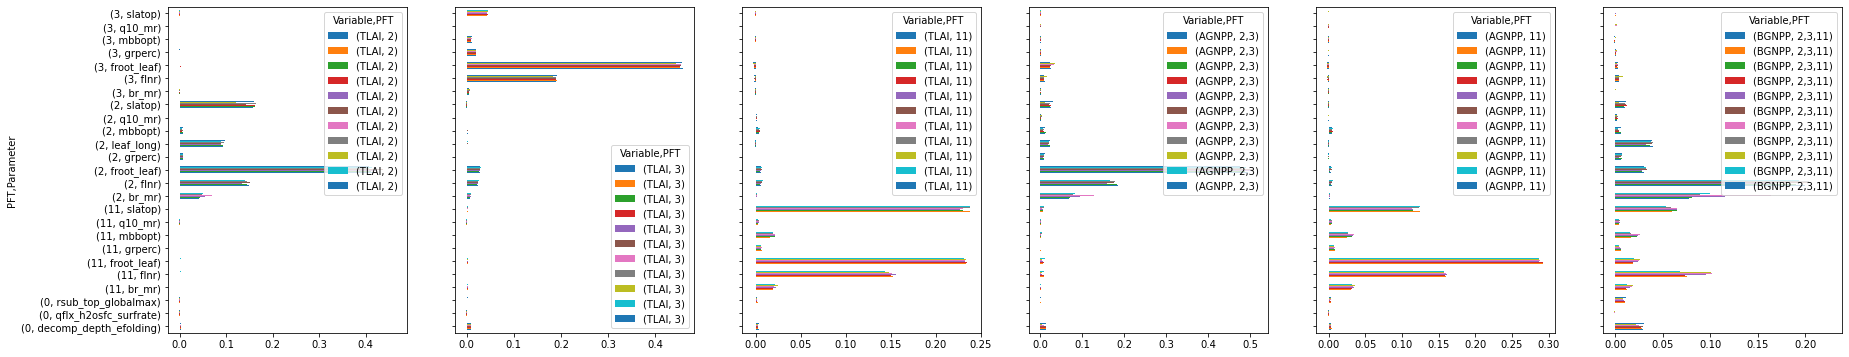

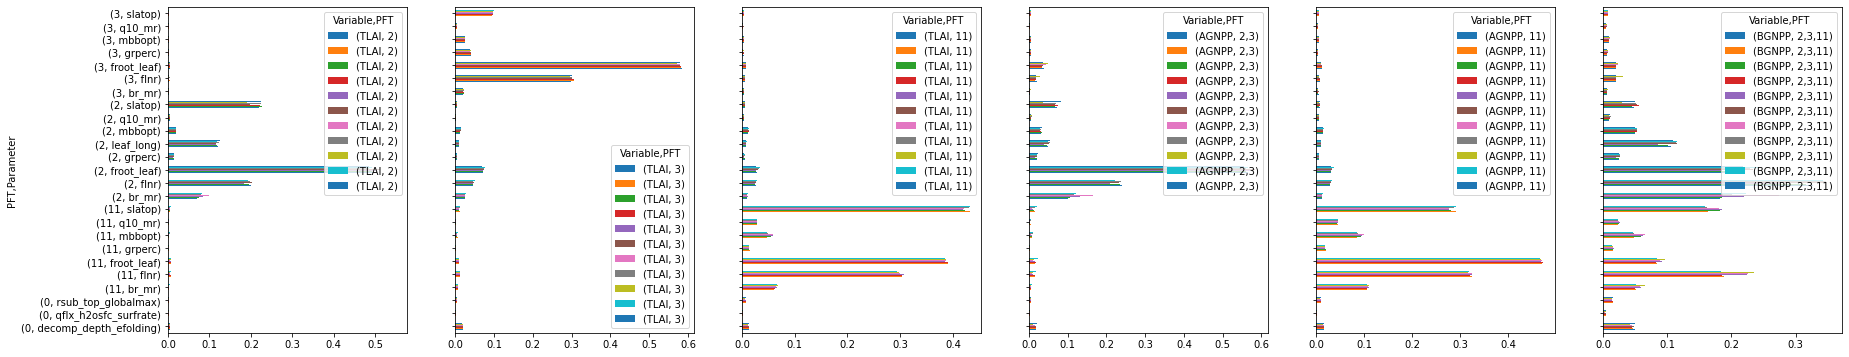

In [48]:
""" Recreate the sensitivity analysis graph """
# the rows are parameters, columns are observations
postproc_vars = pd.read_csv('./temp/postproc_vars_SPRUCE', sep = r'\s+')
colnames = pd.MultiIndex.from_tuples([(i, j) for i, j in zip(postproc_vars['#Variable'], postproc_vars['add'])], names = ['Variable', 'PFT'])
params = param_list('parm_list_SPRUCE_default_no_sphagnum_second_trial')

#Plot main sensitivity indices
filename = os.path.join(os.environ['HOME'], 'models', 'OLMT', 'UQ_output', casename, 'GSA', 'sens_main.txt')
sens_main = pd.read_csv(filename, sep = r'\s+', header = None)
sens_main.columns = colnames
sens_main.index = params
sens_main = sens_main.sort_index().sort_index(axis = 1)

fig, axes = plt.subplots(1, 6, figsize = (30, 6), sharey = True)
sens_main.loc[:, ('TLAI', '2')].plot.barh(ax = axes.flat[0])
sens_main.loc[:, ('TLAI', '3')].plot.barh(ax = axes.flat[1])
sens_main.loc[:, ('TLAI', '11')].plot.barh(ax = axes.flat[2])
sens_main.loc[:, ('AGNPP', '2,3')].plot.barh(ax = axes.flat[3])
sens_main.loc[:, ('AGNPP', '11')].plot.barh(ax = axes.flat[4])
sens_main.loc[:, ('BGNPP', '2,3,11')].plot.barh(ax = axes.flat[5])

#Total sensitivity indices
filename = os.path.join(os.environ['HOME'], 'models', 'OLMT', 'UQ_output', casename, 'GSA', 'sens_tot.txt')
sens_tot = pd.read_csv(filename, sep = r'\s+', header = None)
sens_tot.columns = colnames
sens_tot.index = params
sens_tot = sens_tot.sort_index().sort_index(axis = 1)

fig, axes = plt.subplots(1, 6, figsize = (30, 6), sharey = True)
sens_tot.loc[:, ('TLAI', '2')].plot.barh(ax = axes.flat[0])
sens_tot.loc[:, ('TLAI', '3')].plot.barh(ax = axes.flat[1])
sens_tot.loc[:, ('TLAI', '11')].plot.barh(ax = axes.flat[2])
sens_tot.loc[:, ('AGNPP', '2,3')].plot.barh(ax = axes.flat[3])
sens_tot.loc[:, ('AGNPP', '11')].plot.barh(ax = axes.flat[4])
sens_tot.loc[:, ('BGNPP', '2,3,11')].plot.barh(ax = axes.flat[5])

In [218]:
""" TRY database """
data = pd.read_csv(os.path.join(path_input, '25911.txt'), sep = '\t', encoding = 'ISO-8859-1')
data = data.loc[data['TraitID'].isin([12, 1778, 146, 4083, 3086, 3115, 3116, 3117]), ['DataName', 'AccSpeciesName', 'OrigValueStr', 'UnitName']]
data['OrigValueStr'] = data['OrigValueStr'].astype(float)
data = pd.concat([data.groupby(['DataName', 'AccSpeciesName']).mean(), data.groupby(['DataName', 'AccSpeciesName']).std(), data.groupby(['DataName', 'AccSpeciesName']).first()['UnitName']], axis = 1)
data.columns = ['ValueMean', 'ValueStd', 'Unit']
# data.index = data.index.reorder_levels(['AccSpeciesName', 'DataName'])
# data = data.sort_index()
filt_sla = data.index.get_level_values('DataName').isin(['SLA: petiole  excluded', 'SLA: petiole  included', 'SLA: petiole included (1)', 'SLA: undefined if petiole in- or excluded', 'SLA: undefined if petiole in- or excluded (1)'])
data.loc[filt_sla, 'ValueMean'] = data.loc[filt_sla, 'ValueMean'] / 1000.
data.loc[filt_sla, 'ValueStd'] = data.loc[filt_sla, 'ValueStd'] / 1000.
data.loc[filt_sla, 'Unit'] = 'm2 g-1'
data

<ipython-input-218-8ee9d8b64f71>:2: DtypeWarning: Columns (17) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(os.path.join(path_input, '25911.txt'), sep = '\t', encoding = 'ISO-8859-1')


ValueMean  \
DataName                                           AccSpeciesName                       
Annual turnover of foliage (fraction of total l... Larix laricina            1.000000   
                                                   Picea mariana             0.150000   
Leaf carbon/nitrogen (C/N) ratio                   Larix laricina           27.558010   
                                                   Picea mariana            61.074764   
                                                   Vaccinium angustifolium  26.600249   
Leaf lifespan (longevity, retention time, LL, LLS) Chamaedaphne calyculata  12.916168   
                                                   Kalmia polifolia         18.098504   
                                                   Larix laricina            6.005119   
                                                   Picea mariana            61.522169   
Leaf specific area (SLA): petiole excluded  (max)  Vaccinium oxycoccos       7.120455   
Leaf specific area (SLA): petiole excluded (min)   Vaccinium oxycoccos       6.160000   
SLA: petiole  excluded                             Chamaedaphne calyculata   0.115563   
                                                   Kalmia polifolia          0.130000   
                                                   Larix laricina            0.146291   
                                                   Picea mariana             0.099079   
                                                   Vaccinium angustifolium   0.082250   
                                                   Vaccinium oxycoccos       0.025764   
SLA: petiole  included                             Chamaedaphne calyculata   0.085114   
                                                   Kalmia polifolia          0.070795   
                                                   Picea mariana             0.003921   
                                                   Vaccinium angustifolium   0.229476   
                                                   Vaccinium oxycoccos       0.013082   
SLA: petiole included (1)                          Picea mariana             0.005818   
SLA: undefined if petiole in- or excluded          Chamaedaphne calyculata   0.078662   
                                                   Kalmia polifolia          0.096964   
                                                   Larix laricina            0.068625   
                                                   Picea mariana             0.049569   
                                                   Vaccinium angustifolium   7.987903   
                                                   Vaccinium oxycoccos       0.091000   
SLA: undefined if petiole in- or excluded (1)      Chamaedaphne calyculata   0.101248   
                                                   Kalmia polifolia          0.106379   
                                                   Larix laricina            0.101667   
                                                   Picea mariana             0.105281   
                                                   Vaccinium oxycoccos       0.099865   

                                                                             ValueStd  \
DataName                                           AccSpeciesName                       
Annual turnover of foliage (fraction of total l... Larix laricina                 NaN   
                                                   Picea mariana                  NaN   
Leaf carbon/nitrogen (C/N) ratio                   Larix laricina           11.469434   
                                                   Picea mariana            24.838945   
                                                   Vaccinium angustifolium   5.501733   
Leaf lifespan (longevity, retention time, LL, LLS) Chamaedaphne calyculata   5.769865   
                                                   Kalmia polifolia          0.139306   
                                                   Larix laricina     